In [1]:
import pandas as pd
import numpy as np
import simplejson
import torch
import lightning as L
from Utils import get_tt_split

In [4]:
ln_data = pd.read_excel('../data/lymph_node_data.xlsx')
ln_data.head()

,Dummy ID,ROI,Age at Diagnosis (Calculated),Pathological Grade,Gender,Race,Therapeutic combination,Tm Laterality (R/L),Tumor subsite (BOT/Tonsil/Soft Palate/Pharyngeal wall/GPS/NOS),HPV/P16 status,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
0,10001,GTVp1,54.394444,II,Male,White/Caucasion,Radiation alone,L,Tonsil,Unknown,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
1,10184,NaN,63.130556,II,Male,White/Caucasion,CC,L,Tonsil,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10009,GTVp1,55.447222,III,Female,White/Caucasion,Radiation alone,R,Tonsil,Unknown,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
3,10010,NaN,73.050000,III,Male,White/Caucasion,Radiation alone,Bilateral,NOS,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10069,GTVp1,60.525000,NaN,Male,White/Caucasion,IC+Radiation alone,L,Tonsil,Unknown,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [5]:
ln_data = ln_data.rename({'Dummy ID': 'ID'},axis=1).set_index('ID')
ln_data.head()

,ROI,Age at Diagnosis (Calculated),Pathological Grade,Gender,Race,Therapeutic combination,Tm Laterality (R/L),Tumor subsite (BOT/Tonsil/Soft Palate/Pharyngeal wall/GPS/NOS),HPV/P16 status,Affected Lymph node,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
ID,,,,,,,,,,,,,,,,,,,,,
10001,GTVp1,54.394444,II,Male,White/Caucasion,Radiation alone,L,Tonsil,Unknown,NaN,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
10184,NaN,63.130556,II,Male,White/Caucasion,CC,L,Tonsil,Unknown,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10009,GTVp1,55.447222,III,Female,White/Caucasion,Radiation alone,R,Tonsil,Unknown,NaN,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
10010,NaN,73.050000,III,Male,White/Caucasion,Radiation alone,Bilateral,NOS,Unknown,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10069,GTVp1,60.525000,NaN,Male,White/Caucasion,IC+Radiation alone,L,Tonsil,Unknown,NaN,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [11]:
radiomic_cols = [c for c in ln_data.columns if c[0] == 'F' and '-' in c]
rm = ln_data[radiomic_cols].fillna(0)
rm.head()

,F2-GrayLevelCooccurenceMatrix2590-4ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-5ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-6ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-7ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-1ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-2ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-3ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-4ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-5ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-6ClusterTendendcy,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
ID,,,,,,,,,,,,,,,,,,,,,
10001,2169.381070,2004.708495,1858.470787,1734.634735,1996.668300,1542.119170,1419.922264,1420.754836,1433.812698,1410.230095,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
10184,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
10009,2503.705527,2258.113520,1995.820593,1703.374488,2308.163473,1649.224538,1586.523120,1631.963532,1660.486979,1709.550840,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
10010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
10069,957.125333,849.701668,794.556584,739.654003,1127.261727,864.073903,820.264055,835.117929,840.909730,837.959249,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [59]:
train_ids, test_ids = get_tt_split()
train_ids = [c for c in rm.index.values if c not in test_ids]
rm.loc[train_ids].shape,rm.loc[test_ids].shape

((497, 3367), (147, 3367))

lightning.pytorch.core.module.LightningModule

In [186]:

class Encoder(torch.nn.Module):
    def __init__(self,
                 input_shape,
                 embedding_size = 5,
                 hidden_dims = [10,10,10],
                 input_dropout = .1,
                 pre_embedding_dropout = 0,
                 activation = torch.nn.ReLU,
                ):
        super().__init__()
        modules = []
        self.input_dropout = torch.nn.Dropout(input_dropout)
        currdim = input_shape
        for hd in hidden_dims:
            modules.append(torch.nn.Linear(currdim, hd))
            if activation is not None:
                modules.append(activation())
            currdim = hd
        self.hidden_layers = torch.nn.Sequential(*modules)
        self.embedding_layer_mean = torch.nn.Linear(currdim,embedding_size)
        self.embedding_layer_std = torch.nn.Linear(currdim,embedding_size)
        self.pre_embedding_dropout = torch.nn.Dropout(pre_embedding_dropout)
        

    def forward(self, x):
        x = self.input_dropout(x)
        x = self.hidden_layers(x)
        x = self.pre_embedding_dropout(x)
        mu = self.embedding_layer_mean(x)
        logvar = self.embedding_layer_std(x)
        
        return mu,logvar

class Decoder(torch.nn.Module):
    def __init__(self,
                 output_shape,
                 embedding_size = 5,
                 hidden_dims = [10,10,10],
                 penultimate_dropout = .1,
                 embedding_dropout = 0,
                 activation = None,
                ):
        super().__init__()
        modules = []
        currdim = embedding_size
        for hd in hidden_dims:
            modules.append(torch.nn.Linear(currdim, hd))
            if activation is not None:
                modules.append(activation())
            currdim = hd
        self.hidden_layers = torch.nn.Sequential(*modules)
        self.embedding_dropout = torch.nn.Dropout(embedding_dropout)
        self.penultimate_dropout = torch.nn.Dropout(penultimate_dropout)
        self.output_layer = torch.nn.Linear(currdim,output_shape)
        
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) from
        N(0,1).
        :param mu: (Tensor) Mean of the latent Gaussian [B x D]
        :param logvar: (Tensor) Standard deviation of the latent Gaussian [B x D]
        :return: (Tensor) [B x D]
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu
    
        
    def final_transform(self,x):
        #for subclass options
        return x

    def forward(self, xmu,xlogvar):
        x = self.reparameterize(xmu,xlogvar)
        x = self.embedding_dropout(x)
        x = self.hidden_layers(x)
        x = self.penultimate_dropout(x)
        x = self.output_layer(x)
        return self.final_transform(x)
    
class RadiomicsVAE(L.LightningModule):
    def __init__(self, input_shape, embedding_size,encoder_args={},decoder_args={},kld_weight=.05,mse_weight=1,lr=.01):
        self.lr=lr
        super().__init__()
        self.encoder = Encoder(input_shape,embedding_size=embedding_size,**encoder_args)
        self.decoder = Decoder(input_shape,embedding_size=embedding_size,**decoder_args)
        self.kld_weight = kld_weight
        self.mse_weight = mse_weight
        

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        x = batch
        x = x.view(x.size(0), -1)
        mu,lvar = self.encoder(x)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + lvar - mu ** 2 - lvar.exp(), dim = 1), dim = 0)
        x_hat = self.decoder(mu,lvar)
        mse_loss = torch.nn.functional.mse_loss(x_hat, x)
        
        return self.mse_weight*mse_loss + self.kld_weight*kld_loss
    
    def validation_step(self, batch, batch_idx):
        # training_step defines the train loop.
        x = batch
        x = x.view(x.size(0), -1)
        mu,lvar = self.encoder(x)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + lvar - mu ** 2 - lvar.exp(), dim = 1), dim = 0)
        self.log('val_kld_loss',kld_loss)
        x_hat = self.decoder(mu,lvar)
        mse_loss = torch.nn.functional.mse_loss(x_hat, x)
        self.log("val_mse_loss",mse_loss)
        val_loss = self.mse_weight*mse_loss + self.kld_weight*kld_loss
        self.log("val_loss",val_loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer
    
model = RadiomicsVAE(x.shape[1],2)
model

RadiomicsVAE(
  (encoder): Encoder(
    (input_dropout): Dropout(p=0.1, inplace=False)
    (hidden_layers): Sequential(
      (0): Linear(in_features=3367, out_features=10, bias=True)
      (1): ReLU()
      (2): Linear(in_features=10, out_features=10, bias=True)
      (3): ReLU()
      (4): Linear(in_features=10, out_features=10, bias=True)
      (5): ReLU()
    )
    (embedding_layer_mean): Linear(in_features=10, out_features=2, bias=True)
    (embedding_layer_std): Linear(in_features=10, out_features=2, bias=True)
    (pre_embedding_dropout): Dropout(p=0, inplace=False)
  )
  (decoder): Decoder(
    (hidden_layers): Sequential(
      (0): Linear(in_features=2, out_features=10, bias=True)
      (1): Linear(in_features=10, out_features=10, bias=True)
      (2): Linear(in_features=10, out_features=10, bias=True)
    )
    (embedding_dropout): Dropout(p=0, inplace=False)
    (penultimate_dropout): Dropout(p=0.1, inplace=False)
    (output_layer): Linear(in_features=10, out_features=3367

In [187]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

BATCHSIZE = 10
[xtrain,xval] = [torch.from_numpy(rm.loc[ids].values.astype('float')).type(torch.float32) for ids in [train_ids,test_ids]]
normalize = lambda xx: (xx - xtrain.mean(axis=0))/(xtrain.std(axis=0) + .1)
convert = lambda x: torch.utils.data.DataLoader(normalize(x),batch_size=BATCHSIZE)
es = EarlyStopping(monitor='val_loss',mode='min',patience=20)
trainer = L.Trainer(max_epochs=1000,callbacks=[es])
torch.set_float32_matmul_precision('medium')
trainer.fit(model,convert(xtrain),convert(xval))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | encoder | Encoder | 33.9 K | train
1 | decoder | Decoder | 37.3 K | train
--------------------------------------------
71.2 K    Trainable params
0         Non-trainable params
71.2 K    Total params
0.285     Total estimated model params size (MB)
20        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

In [188]:
xall = torch.concat([xtrain,xval],axis=0)
trainer.validate(model,convert(xall))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |                                             | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_kld_loss          1.2477235794067383
        val_loss            0.4086560606956482
      val_mse_loss          0.3462699055671692
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_kld_loss': 1.2477235794067383,
  'val_mse_loss': 0.3462699055671692,
  'val_loss': 0.4086560606956482}]

In [189]:
with torch.no_grad():
    embedding = model.decoder.reparameterize(*model.encoder(normalize(xall))).detach().cpu().numpy()
embedding

array([[-0.74639356,  0.49521694],
       [ 2.1430755 , -2.0821524 ],
       [-0.8728189 ,  0.5034363 ],
       ...,
       [ 0.6703546 ,  0.10191569],
       [-0.20563819,  0.5863125 ],
       [ 0.89706063, -0.3184636 ]], dtype=float32)

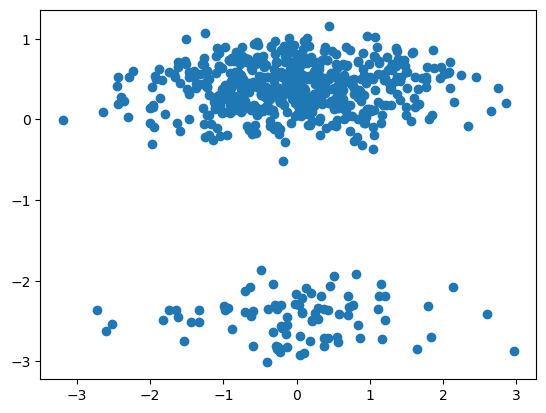

In [190]:
import matplotlib.pyplot as plt
plt.scatter(embedding[:,0],embedding[:,1])